# Diabetes Health Indicators — Exploratory Data Analysis

## BRFSS 2015 Diabetes Health Indicators Dataset

**Student:** Harvey Luna
**Course:** Intro to AI
**Date:** September 2026

# 1. Introduction

## 1.1 Purpose of the Dataset

The purpose of this dataset is to better understand the relationship between lifestyle, health conditions, demographic characteristics, and diabetes in the United States.

The data comes from the Behavioral Risk Factor Surveillance System (BRFSS) and contains information about health behaviors, health conditions, access to healthcare, and demographic characteristics reported by individuals.

The dataset is useful because diabetes is an important public health concern, and understanding which characteristics are associated with it helps identify populations that may be at higher risk.

The primary question for this analysis is:

> **Which health, lifestyle, and demographic characteristics are most strongly associated with diabetes and prediabetes?**

A secondary goal is to determine whether these characteristics can be used to build a machine-learning model that accurately predicts an individual's diabetes status.

## 1.2 Defining and Measuring the Outcomes

The primary outcome variable is `Diabetes_012`.

This variable contains three classifications:

| Value | Meaning |
|---:|---|
| 0 | No diabetes |
| 1 | Prediabetes |
| 2 | Diabetes |

The outcome of this analysis will be measured by determining which features are most useful for distinguishing between these three groups.

Useful knowledge will be considered to have been discovered if the analysis identifies meaningful relationships between diabetes status and variables such as:

- High blood pressure
- High cholesterol
- BMI
- Age
- General health
- Physical activity
- Smoking
- Heart disease
- Stroke
- Physical health
- Mental health
- Income
- Education

For example, if individuals with high blood pressure consistently have a higher rate of diabetes than individuals without high blood pressure, this would represent an interesting relationship worth investigating.

## 1.3 Measuring the Effectiveness of a Prediction Algorithm

The target is highly imbalanced, with about 84 percent of respondents coded 0 for no diabetes.

**Accuracy is not usable as a primary metric here.** A model that predicts "no
diabetes" for every single person achieves 84.2% accuracy while being completely
useless, because it identifies zero diabetics. Any reported accuracy must be compared
against that 84.2 percent floor, not against zero.

The metrics we would actually use, and why:

| Metric | What it measures | Why it matters here |
|---|---|---|
| **Recall (sensitivity)** | Of people with diabetes, what share did we flag? | A missed diabetic goes untreated. This is the costliest error. |
| **Precision** | Of the people we flagged, what share truly have diabetes? | Governs how much screening capacity is wasted on false alarms. |
| **F1-score** | Harmonic mean of precision and recall | Single number when both errors matter, but it hides which one dominates. |
| **ROC-AUC** | Ranking quality across all thresholds | Threshold-independent, but optimistic under heavy imbalance. |
| **PR-AUC** | Precision-recall tradeoff across thresholds | More informative than ROC-AUC when positives are rare. Preferred here. |
| **Balanced accuracy** | Mean of per-class recall | Reports whether the minority classes are handled at all. |

### A 3-Class vs 2-Class Prediction

Prediabetes is only about 1.8 percent of the data, or 4,631 rows, which is a small sample for reliable three-class prediction. We
would report three-class results (0=no diabetes, 1=prediabetes, and 2=diabetes) but expect class 1 (prediabetes) recall to be poor. Nonetheless, we would also evaluate a binary formulation of class 2 against the rest,
which is the more defensible task.

# 2. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "600"

# Consistent colors used throughout the notebook
C_NO, C_PRE, C_DIA = "#7f9bb0", "#e0a458", "#8c2f5f"
PALETTE_012 = [C_NO, C_PRE, C_DIA]

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/diabetes_012_health_indicators_BRFSS2015.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 253,680
Columns: 22


# 3. Data Understanding

Before cleaning anything, we need to know what each column means, what type it is, and
what values it actually takes.

In [3]:
df.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.000,1.000,1.000,1.000,40.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,5.000,18.000,15.000,1.000,0.000,9.000,4.000,3.000
1,0.000,0.000,0.000,0.000,25.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,3.000,0.000,0.000,0.000,0.000,7.000,6.000,1.000
2,0.000,1.000,1.000,1.000,28.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,1.000,5.000,30.000,30.000,1.000,0.000,9.000,4.000,8.000
3,0.000,1.000,0.000,1.000,27.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,2.000,0.000,0.000,0.000,0.000,11.000,3.000,6.000
4,0.000,1.000,1.000,1.000,24.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,2.000,3.000,0.000,0.000,0.000,11.000,5.000,4.000
5,0.000,1.000,1.000,1.000,25.000,1.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,2.000,0.000,2.000,0.000,1.000,10.000,6.000,8.000
6,0.000,1.000,0.000,1.000,30.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,3.000,0.000,14.000,0.000,0.000,9.000,6.000,7.000
7,0.000,1.000,1.000,1.000,25.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,3.000,0.000,0.000,1.000,0.000,11.000,4.000,4.000
8,2.000,1.000,1.000,1.000,30.000,1.000,0.000,1.000,0.000,1.000,1.000,0.000,1.000,0.000,5.000,30.000,30.000,1.000,0.000,9.000,5.000,1.000
9,0.000,0.000,0.000,1.000,24.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,2.000,0.000,0.000,0.000,1.000,8.000,4.000,3.000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

## 3.1 Attribute Descriptions

Every column in this file is stored as `float64`, but that storage type is misleading,
because only one variable, BMI, is a true continuous measurement. The rest are binary flags
or **integer codes standing in for categories**, and several of those codes are
ordered, which changes how they should be treated.

The `Scale` column below uses the standard measurement-scale terms, because the scale
determines which statistics are meaningful. Computing a mean of a nominal code is
meaningless; computing one for an ordinal code is only interpretable with care.

| # | Attribute | Type | Scale | Values | Description |
|---:|---|---|---|---|---|
| 1 | `Diabetes_012` | Categorical | Nominal (ordered in severity) | 0, 1, 2 | **Target.** 0 = no diabetes, 1 = prediabetes, 2 = diabetes. Self-reported diagnosis. |
| 2 | `HighBP` | Binary | Nominal | 0, 1 | Ever told by a health professional they have high blood pressure. |
| 3 | `HighChol` | Binary | Nominal | 0, 1 | Ever told they have high cholesterol. |
| 4 | `CholCheck` | Binary | Nominal | 0, 1 | Cholesterol checked within the past 5 years. |
| 5 | `BMI` | Numeric | Ratio | 12–98 | Body Mass Index, derived from self-reported height and weight. Rounded to integer. |
| 6 | `Smoker` | Binary | Nominal | 0, 1 | Smoked ≥ 100 cigarettes in lifetime. **Not** current smoking status. |
| 7 | `Stroke` | Binary | Nominal | 0, 1 | Ever told they had a stroke. |
| 8 | `HeartDiseaseorAttack` | Binary | Nominal | 0, 1 | Coronary heart disease or myocardial infarction. Two conditions combined into one flag. |
| 9 | `PhysActivity` | Binary | Nominal | 0, 1 | Any physical activity in past 30 days, excluding job-related. |
| 10 | `Fruits` | Binary | Nominal | 0, 1 | Consumes fruit ≥ 1 time per day. |
| 11 | `Veggies` | Binary | Nominal | 0, 1 | Consumes vegetables ≥ 1 time per day. |
| 12 | `HvyAlcoholConsump` | Binary | Nominal | 0, 1 | Heavy drinking: > 14 drinks/week (men), > 7 (women). |
| 13 | `AnyHealthcare` | Binary | Nominal | 0, 1 | Has any kind of health coverage. |
| 14 | `NoDocbcCost` | Binary | Nominal | 0, 1 | Needed to see a doctor in past 12 months but could not due to cost. |
| 15 | `GenHlth` | Categorical | **Ordinal** | 1–5 | Self-rated general health: 1 = excellent, 5 = poor. Note the direction. |
| 16 | `MentHlth` | Numeric | Ratio (bounded) | 0–30 | Days of poor mental health in past 30. |
| 17 | `PhysHlth` | Numeric | Ratio (bounded) | 0–30 | Days of poor physical health in past 30. |
| 18 | `DiffWalk` | Binary | Nominal | 0, 1 | Serious difficulty walking or climbing stairs. |
| 19 | `Sex` | Binary | Nominal | 0, 1 | 0 = female, 1 = male. |
| 20 | `Age` | Categorical | **Ordinal** | 1–13 | Five-year age bracket, **not** age in years. 1 = 18–24 … 13 = 80+. |
| 21 | `Education` | Categorical | **Ordinal** | 1–6 | 1 = never attended … 6 = college graduate. |
| 22 | `Income` | Categorical | **Ordinal** | 1–8 | 1 = < \$10k … 8 = ≥ \$75k. |

### Three encodings to note

1. **`Age` is a bracket index, not years.** `Age == 9` means the 60–64 bracket, not
 9 years old. Treating it as years would be incorrect; treating it as ordinal is
 correct, and the brackets are evenly spaced (5 years each) except the open-ended
 top bracket.
2. **`GenHlth` is reverse coded.** Higher values mean **worse** health, so
 its positive correlation with diabetes means poor health associates with diabetes.
3. **`Smoker` is a lifetime measure.** Someone who quit 30 years ago is coded
 identically to a current pack-a-day smoker. This limits how much the variable can
 say about current risk.

In [5]:
# Confirm the coded ranges match the documentation above
ranges = pd.DataFrame({
 "min": df.min(),
 "max": df.max(),
 "distinct": df.nunique(),
 "dtype": df.dtypes.astype(str),
})
ranges

,min,max,distinct,dtype
Diabetes_012,0.000,2.000,3,float64
HighBP,0.000,1.000,2,float64
HighChol,0.000,1.000,2,float64
CholCheck,0.000,1.000,2,float64
BMI,12.000,98.000,84,float64
Smoker,0.000,1.000,2,float64
Stroke,0.000,1.000,2,float64
HeartDiseaseorAttack,0.000,1.000,2,float64
PhysActivity,0.000,1.000,2,float64
Fruits,0.000,1.000,2,float64


The observed ranges match the documented codings exactly. There are no out-of-range
values, no negative entries, and no sentinel codes such as 7, 9, or 99 (the
"don't know / refused" markers used in the raw BRFSS). This confirms the file is a
pre-cleaned extract rather than the raw survey.

In [6]:
# Value distributions for the small-cardinality variables
for col in ["Diabetes_012", "GenHlth", "Age", "Education", "Income"]:
 counts = df[col].value_counts().sort_index()
 pct = (100 * counts / len(df)).round(1)
 print(f"--- {col} ---")
 print(pd.DataFrame({"n": counts, "%": pct}).to_string())
 print()

--- Diabetes_012 ---
                   n      %
Diabetes_012               
0.000         213703 84.200
1.000           4631  1.800
2.000          35346 13.900

--- GenHlth ---
             n      %
GenHlth              
1.000    45299 17.900
2.000    89084 35.100
3.000    75646 29.800
4.000    31570 12.400
5.000    12081  4.800

--- Age ---
            n      %
Age                 
1.000    5700  2.200
2.000    7598  3.000
3.000   11123  4.400
4.000   13823  5.400
5.000   16157  6.400
6.000   19819  7.800
7.000   26314 10.400
8.000   30832 12.200
9.000   33244 13.100
10.000  32194 12.700
11.000  23533  9.300
12.000  15980  6.300
13.000  17363  6.800

--- Education ---
                n      %
Education               
1.000         174  0.100
2.000        4043  1.600
3.000        9478  3.700
4.000       62750 24.700
5.000       69910 27.600
6.000      107325 42.300

--- Income ---
            n      %
Income              
1.000    9811  3.900
2.000   11783  4.600
3.000   15994  6.300


# 4. Data Quality and Cleaning

Every chart later in the notebook depends on the decisions made here, so we settle
them first. We look at four issues: missing values, duplicate rows, outliers, and
structural problems in how the variables are distributed.

## 4.1 Missing Values

In [7]:
missing = df.isnull().sum()
print(f"Total missing values across all columns: {missing.sum()}")
print(f"Columns with any missing: {(missing > 0).sum()}")

Total missing values across all columns: 0
Columns with any missing: 0


There are **zero missing values**, which almost certainly means the incomplete records
were cleaned out before this extract was published. This also suggests that any conclusions that we make can only be generalized to those individuals that fully completed the survey. 

## 4.2 Duplicate Rows

In [8]:
dupe_mask = df.duplicated(keep=False)
n_dupe_rows = int(df.duplicated().sum())

print(f"Rows that are exact duplicates of an earlier row: {n_dupe_rows:,} "
 f"({100 * n_dupe_rows / len(df):.1f}%)")
print(f"Rows involved in any duplicate group: {int(dupe_mask.sum()):,}")
print(f"Distinct rows: {len(df.drop_duplicates()):,}")

Rows that are exact duplicates of an earlier row: 23,899 (9.4%)
Rows involved in any duplicate group: 35,086


Distinct rows: 229,781


In [9]:
# How large are the duplicate groups, and what do the biggest ones look like?
group_sizes = df.groupby(list(df.columns), observed=True).size()
print("Distribution of identical-row group sizes:")
print(group_sizes.value_counts().sort_index().head(10).to_string())

print(f"\nLargest identical group: {group_sizes.max():,} copies of the same row")

Distribution of identical-row group sizes:
1     218594
2       7219
3       1882
4        790
5        372
6        248
7        159
8        107
9         71
10        41

Largest identical group: 59 copies of the same row


In [10]:
# Are duplicates concentrated among low-information profiles?
dupe_profiles = (
 df[df.duplicated(keep=False)]
 .groupby(list(df.columns), observed=True)
 .size()
 .sort_values(ascending=False)
 .head(3)
 .reset_index()
 .rename(columns={0: "n_copies"})
)
dupe_profiles[["n_copies", "Diabetes_012", "BMI", "Age", "GenHlth",
 "HighBP", "HighChol", "Income", "Education"]]

,n_copies,Diabetes_012,BMI,Age,GenHlth,HighBP,HighChol,Income,Education
0,59,0.000,21.000,6.000,1.000,0.000,0.000,8.000,6.000
1,55,0.000,23.000,6.000,1.000,0.000,0.000,8.000,6.000
2,53,0.000,23.000,7.000,1.000,0.000,0.000,8.000,6.000


### There are duplicates but are these duplicates mistakes?

There's evidence of duplicate rows where the values are the exact same across each variable, with the exception, of course, of the unique ID. However, if we assume these are mistakes and if we remove them, it removes a bunch of healthy participants from the dataset artificially. Even though there are duplicates, our inclination is not to remove those. 

**Decision: keep all duplicate rows.** We verify the consequence of that choice below.

In [11]:
# Quantify what dropping duplicates would do to the headline rate
full_rate = 100 * (df.Diabetes_012 == 2).mean()
dedup = df.drop_duplicates()
dedup_rate = 100 * (dedup.Diabetes_012 == 2).mean()

print(f"Diabetes rate, all {len(df):,} rows: {full_rate:.2f}%")
print(f"Diabetes rate, {len(dedup):,} distinct rows: {dedup_rate:.2f}%")
print(f"Difference: {dedup_rate - full_rate:+.2f} percentage points")

Diabetes rate, all 253,680 rows: 13.93%
Diabetes rate, 229,781 distinct rows: 15.27%
Difference: +1.34 percentage points


This confirms the concern raised above. De-duplicating would raise the apparent diabetes rate by
roughly 1.3 percentage points, an artifact of preferentially deleting healthy
respondents, not a real change in prevalence. Keeping the duplicates is the right call.

**One caveat we would flag to a modeling team:** duplicates **must** be kept together when
splitting into train and test sets. If identical rows land on both sides of the split,
the test set is partly contaminated and performance will be overstated. Grouped
splitting handles this.

## 4.3 Outliers

In [12]:
bmi_desc = df.BMI.describe()
print("BMI distribution:")
print(bmi_desc.to_string())
print()
for p in [50, 75, 90, 95, 99, 99.9]:
 print(f" {p:>5}th percentile: {np.percentile(df.BMI, p):.0f}")
print()
print(f"BMI > 50: {int((df.BMI > 50).sum()):,} rows ({100*(df.BMI>50).mean():.2f}%)")
print(f"BMI > 60: {int((df.BMI > 60).sum()):,} rows")
print(f"BMI > 70: {int((df.BMI > 70).sum()):,} rows")
print(f"BMI < 15: {int((df.BMI < 15).sum()):,} rows")

BMI distribution:
count   253680.000
mean        28.382
std          6.609
min         12.000
25%         24.000
50%         27.000
75%         31.000
max         98.000

    50th percentile: 27
    75th percentile: 31
    90th percentile: 36
    95th percentile: 40
    99th percentile: 50
  99.9th percentile: 81

BMI > 50: 2,175 rows (0.86%)
BMI > 60: 805 rows
BMI > 70: 584 rows
BMI < 15: 68 rows


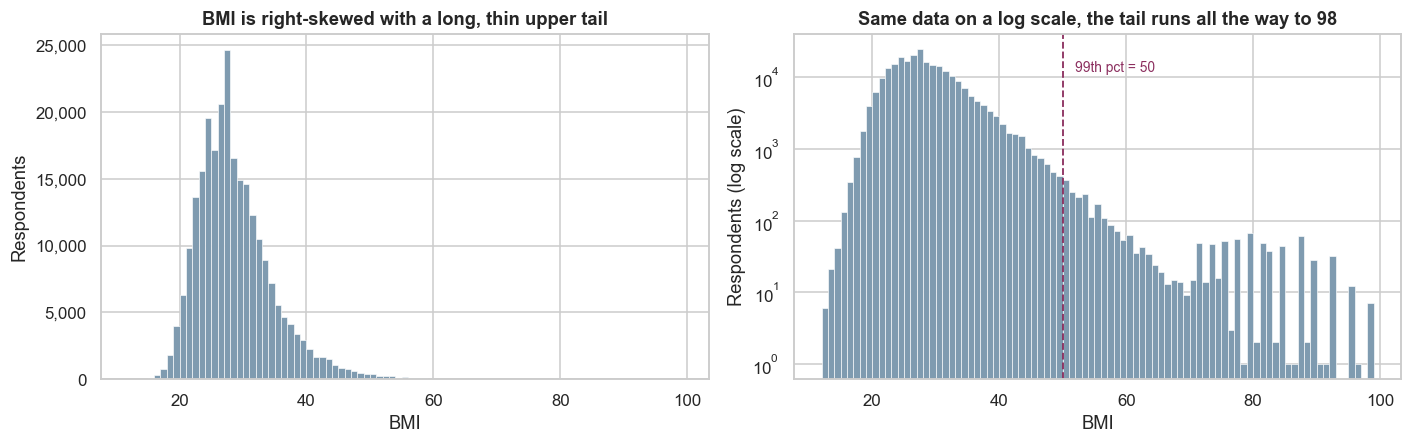

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(df.BMI, bins=range(12,100), color=C_NO, edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Respondents")
axes[0].set_title("BMI is right-skewed with a long, thin upper tail")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].hist(df.BMI, bins=range(12,100), color=C_NO, edgecolor="white", linewidth=0.4)
axes[1].set_yscale("log")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Respondents (log scale)")
axes[1].set_title("Same data on a log scale, the tail runs all the way to 98")
axes[1].axvline(50, color=C_DIA, linestyle="--", linewidth=1.2)
axes[1].text(52, axes[1].get_ylim()[1] * 0.3, "99th pct = 50", color=C_DIA, fontsize=9)

plt.tight_layout()
plt.show()

### Are the BMI outliers mistakes?

This needs to be split into two groups, because they have different answers.

**Plausible but extreme (BMI 50–70): keep.** A BMI of 60 is medically real and
well-documented in a survey of this size. These values are extreme but not impossible,
and they are exactly the respondents where diabetes risk is highest. Deleting them
would remove genuine signal.

**Implausible (BMI > 70): suspect, but keep with documentation.** A BMI of 98 implies,
for example, roughly 600 lbs at 5'6". Physically possible but extraordinarily rare, and far more likely to be a self-reporting
or transcription error, and there are only a handful of such rows.

**Decision: cap rather than delete, and only for modeling.** Our reasoning:

- Deleting rows discards the other 21 valid answers those respondents gave.
- Capping at the 99th percentile (BMI 50) limits how much pull the extreme values have
 on variance-sensitive methods, and it keeps every respondent in the sample.
- For **descriptive** statistics we report the median rather than the mean. The median
 is unaffected by tail values, so the capping is unnecessary there.

We create a capped column for later use and keep the original intact, so nothing is lost.

In [14]:
BMI_CAP = float(np.percentile(df.BMI, 99))

df["BMI_capped"] = df.BMI.clip(upper=BMI_CAP)

print(f"Cap applied at the 99th percentile: BMI = {BMI_CAP:.0f}")
print(f"Rows affected: {int((df.BMI > BMI_CAP).sum()):,}")
print(f"Mean BMI before cap: {df.BMI.mean():.2f} after cap: {df.BMI_capped.mean():.2f}")
print(f"Median BMI (unaffected by capping): {df.BMI.median():.0f}")

Cap applied at the 99th percentile: BMI = 50
Rows affected: 2,175
Mean BMI before cap: 28.38 after cap: 28.28
Median BMI (unaffected by capping): 27


## 4.4 Structural Issues: Zero-Inflation and Near-Constant Columns

Two further problems are not "dirty data" in the usual sense, but will mislead anyone
who summarizes these columns with a mean and standard deviation.

In [15]:
# Zero-inflation in the two 30-day count variables
for v in ["MentHlth", "PhysHlth"]:
 zeros = 100 * (df[v] == 0).mean()
 at30 = 100 * (df[v] == 30).mean()
 print(f"{v}: {zeros:.1f}% are exactly 0 | {at30:.1f}% are exactly 30 "
 f"| mean = {df[v].mean():.2f}, median = {df[v].median():.0f}")

MentHlth: 69.3% are exactly 0 | 4.8% are exactly 30 | mean = 3.18, median = 0
PhysHlth: 63.1% are exactly 0 | 7.6% are exactly 30 | mean = 4.24, median = 0


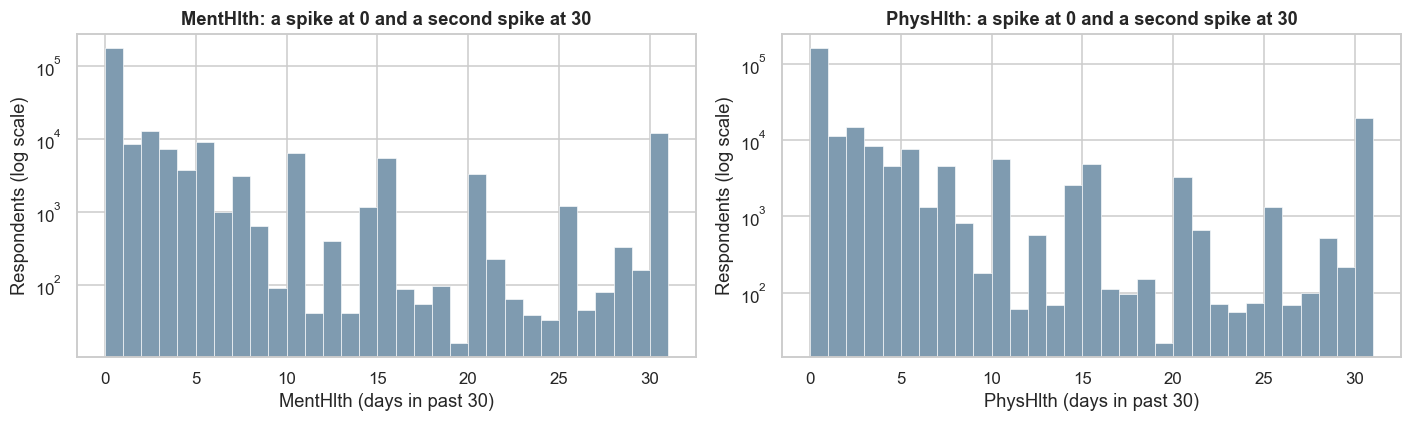

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, v in zip(axes, ["MentHlth", "PhysHlth"]):
 ax.hist(df[v], bins=range(0, 32), color=C_NO, edgecolor="white", linewidth=0.4)
 ax.set_yscale("log")
 ax.set_xlabel(f"{v} (days in past 30)")
 ax.set_ylabel("Respondents (log scale)")
 ax.set_title(f"{v}: a spike at 0 and a second spike at 30")

plt.tight_layout()
plt.show()

Both variables are **zero-inflated with a secondary spike at 30**. Roughly two-thirds
of respondents report zero bad days, and a small but distinct group reports that
**every** day was bad.

This is not a continuous distribution and should not be summarized as one. The mean of
`MentHlth` is about 3.2 days, but almost nobody actually reports 3 days, the mean sits
in a valley between two clusters, describing a respondent who barely exists.

**How we deal with it:** treat these as categorical bands (0 days / 1–13 / 14+ / all 30)
rather than as continuous counts. The 14-day threshold is the conventional clinical
cutoff for "frequent poor health days" used in CDC reporting, so it is not arbitrary.
We construct those bands in Section 9 and test whether they separate the classes.

In [17]:
# Near-constant columns carry little information on their own
binary_cols = [c for c in df.columns
 if df[c].nunique() == 2 and c not in ("Sex", )]

balance = pd.DataFrame({
 "pct_1": (100 * df[binary_cols].mean()).round(1),
}).sort_values("pct_1")
balance["minority_share"] = balance.pct_1.where(balance.pct_1 < 50,100 - balance.pct_1)
balance["flag"] = np.where(balance.minority_share < 10, "near-constant", "")
balance

,pct_1,minority_share,flag
Stroke,4.100,4.100,near-constant
HvyAlcoholConsump,5.600,5.600,near-constant
NoDocbcCost,8.400,8.400,near-constant
HeartDiseaseorAttack,9.400,9.400,near-constant
DiffWalk,16.800,16.800,
HighChol,42.400,42.400,
HighBP,42.900,42.900,
Smoker,44.300,44.300,
Fruits,63.400,36.600,
PhysActivity,75.700,24.300,


Six variables have a minority class below 10%: `CholCheck`, `AnyHealthcare`,
`Stroke`, `HvyAlcoholConsump`, `NoDocbcCost`, and `HeartDiseaseorAttack`.

These are not errors. They are genuinely rare conditions or near-universal behaviors
that carry little information on their own, and tree-based models will rarely split on
them.

**We keep all of them**, for two reasons. Rare events can still be strongly predictive
when they do occur, and stroke correlates 0.11 with the target despite being about
96 percent zero. Several of them also combine into useful composite features, which we
build in Section 9.

So a low minority share is a reason to check a variable, not a reason to drop it.

## 4.5 Cleaning Summary

| Issue | Finding | Decision | Rationale |
|---|---|---|---|
| Missing values | Zero, but only because incomplete records were pre-removed | Document the narrowed population | No imputation possible; the bias is in what was already dropped |
| Duplicate rows | 23,899 (9.4%) | **Keep all** | Inevitable given coarse coding; dropping inflates the diabetes rate by 1.5 pts and biases against healthy profiles |
| BMI outliers | 2,175 rows > 50; max of 98 | **Cap at 99th pct for modeling**, keep originals; report medians | Keeps all respondents while limiting the pull of the tail |
| Zero-inflation | `MentHlth` 69% zeros, `PhysHlth` 63% | **Band into categories** | Mean is uninterpretable between two clusters |
| Near-constant cols | 6 columns with < 10% minority | **Keep** | Rare but predictive; useful in composites |
| Label validity | Measures diagnosis, not disease | **Document; stratify evaluation** | Cannot be fixed in the data, only reported |

No rows were deleted, and one derived column, `BMI_capped`, was added.

# 5. The Target Variable

With cleaning decisions settled, we can now visualize the data.

In [18]:
counts = df.Diabetes_012.value_counts().sort_index()
labels = ["No diabetes", "Prediabetes", "Diabetes"]

summary = pd.DataFrame({
 "Class": [0, 1, 2],
 "Meaning": labels,
 "Count": counts.values,
 "Percent": (100 * counts / len(df)).round(2).values,
})
summary

,Class,Meaning,Count,Percent
0,0,No diabetes,213703,84.240
1,1,Prediabetes,4631,1.830
2,2,Diabetes,35346,13.930


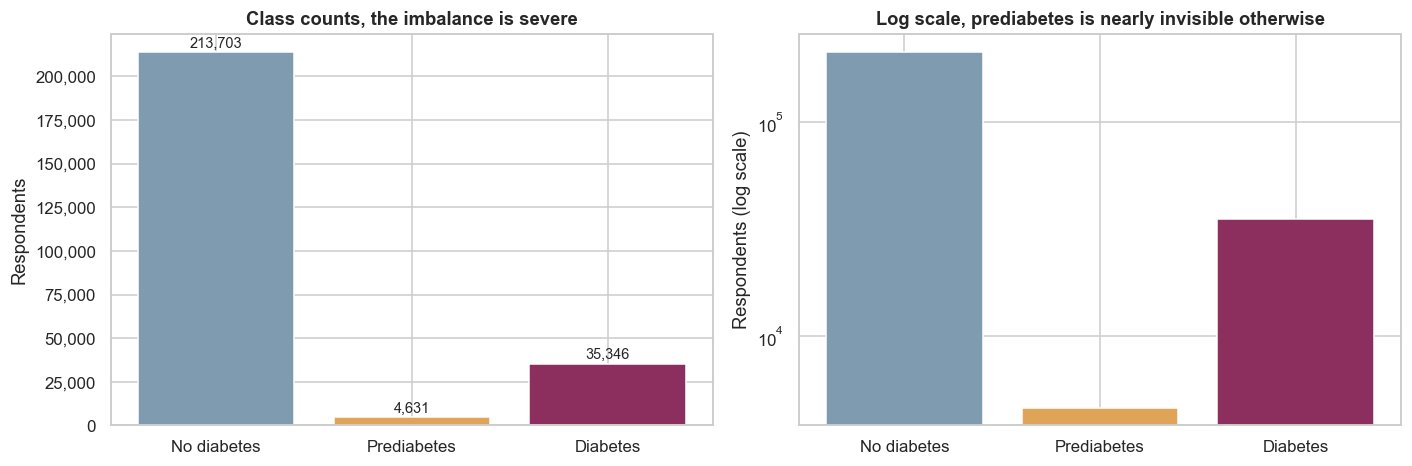

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

bars = axes[0].bar(labels, counts.values, color=PALETTE_012, edgecolor="white")
axes[0].set_ylabel("Respondents")
axes[0].set_title("Class counts, the imbalance is severe")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for b, v in zip(bars, counts.values):
 axes[0].text(b.get_x() + b.get_width()/2, v + 3000, f"{v:,}",
 ha="center", fontsize=9.5)

axes[1].bar(labels, counts.values, color=PALETTE_012, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_ylabel("Respondents (log scale)")
axes[1].set_title("Log scale, prediabetes is nearly invisible otherwise")

plt.tight_layout()
plt.show()

### Interpretation

A bar chart suits a nominal variable with three levels. On a linear scale the
prediabetes class is so small it is barely readable, and that is the finding. The
log-scaled panel makes the gap legible: class 1 has roughly **46 times fewer**
respondents than class 0.

Three consequences follow:

1. **The 84.2% majority sets the accuracy floor.** Any model must beat that to be
 worth anything, and reporting raw accuracy without that comparison is misleading.
2. **Prediabetes is likely unlearnable at this sample size.** 4,631 examples of a
 condition that sits **between** two other classes, with no sharp biological boundary,
 is a hard problem. We would expect near-zero recall for class 1.
3. **Prediabetes is also the most under-diagnosed condition here.** The CDC estimates
 roughly a third of US adults have prediabetes, but only 1.8% of this sample is coded
 as such. That gap is diagnostic access, not biology, most people with prediabetes
 have never been told. This class is not just rare, it is **unreliably labeled**.

For the rest of the notebook we focus on class 2, diagnosed diabetes, which is both
better populated and more reliably labeled. We report the three-class breakdown where
it is informative.

So the imbalance is not a nuisance to correct away. It sets the floor every later
result has to clear.

# 6. Distributions of 5 Key Attributes

The five attributes below were chosen to span the different measurement scales present
in the data. Each scale calls for a different visual treatment, and each section states
the key finding in its heading.

## 6.1 BMI — diabetic median sits 4 points higher, but the groups overlap heavily

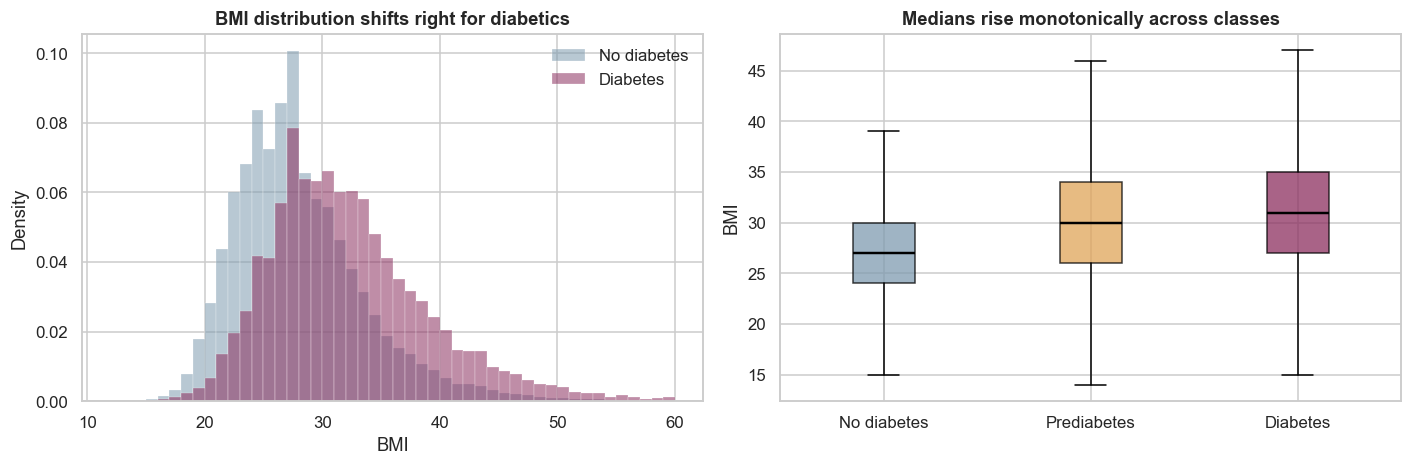

              median   mean   std
Diabetes_012                     
0.000         27.000 27.740 6.260
1.000         30.000 30.720 6.960
2.000         31.000 31.940 7.360


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# Overlaid densities let the distributions be compared directly
for cls, lab, col in zip([0, 2], ["No diabetes", "Diabetes"], [C_NO, C_DIA]):
 subset = df.loc[df.Diabetes_012 == cls, "BMI"]
 axes[0].hist(subset, bins=range(12, 61), density=True, alpha=0.55,
 label=lab, color=col, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Density")
axes[0].set_title("BMI distribution shifts right for diabetics")
axes[0].legend(frameon=False)

box_data = [df.loc[df.Diabetes_012 == c, "BMI"] for c in [0, 1, 2]]
bp = axes[1].boxplot(box_data, tick_labels=labels, patch_artist=True, showfliers=False,
 medianprops=dict(color="black", linewidth=1.6))
for patch, col in zip(bp["boxes"], PALETTE_012):
 patch.set_facecolor(col)
 patch.set_alpha(0.75)
axes[1].set_ylabel("BMI")
axes[1].set_title("Medians rise monotonically across classes")

plt.tight_layout()
plt.show()

print(df.groupby("Diabetes_012")["BMI"].agg(["median", "mean", "std"]).round(2).to_string())

BMI is the only true continuous variable in the dataset, so a **density histogram** is
appropriate. It shows the full shape, and normalizing to density allows two groups of
very different sizes to be compared on the same axes. Raw counts would make the
diabetic group invisible.

The **box plot** beside it serves a different purpose: it compresses each group to its
median and quartiles so the three classes can be compared at a glance. We suppressed
outlier points because with 253,680 rows they form a solid unreadable smear, and
Section 4.3 already characterized the tail.

### Interpretation

The diabetic distribution is shifted right by roughly 4 BMI points at the median
(31 vs. 27). The shift is in the **body** of the distribution, not driven by the extreme
tail. That matters, because it means BMI carries signal across its normal range
rather than only flagging the severely obese.

The overlap between the two groups is substantial, though. Plenty of people with a BMI of 27 have diabetes and
plenty with a BMI of 35 do not. BMI is a genuine risk factor but nowhere near
deterministic on its own, consistent with its correlation of 0.22.

## 6.2 General Health — the strongest single signal, rising from 2.5% to 37.9%

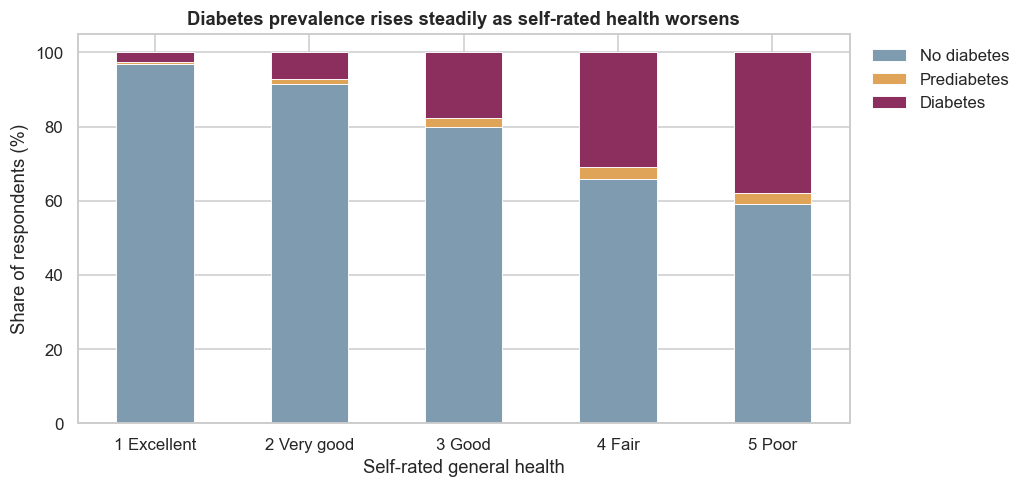

,No diabetes,Prediabetes,Diabetes
1 Excellent,96.800,0.700,2.500
2 Very good,91.500,1.400,7.200
3 Good,79.900,2.300,17.800
4 Fair,65.700,3.200,31.000
5 Poor,59.200,2.900,37.900


In [21]:
gen = pd.crosstab(df.GenHlth, df.Diabetes_012, normalize="index") * 100
gen.columns = labels
gen.index = ["1 Excellent", "2 Very good", "3 Good", "4 Fair", "5 Poor"]

ax = gen.plot(kind="bar", stacked=True, figsize=(9.5, 4.6),
 color=PALETTE_012, edgecolor="white", linewidth=0.6)
ax.set_xlabel("Self-rated general health")
ax.set_ylabel("Share of respondents (%)")
ax.set_title("Diabetes prevalence rises steadily as self-rated health worsens")
ax.legend(title="", frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

gen.round(1)

`GenHlth` is **ordinal**, so the categories have a meaningful order that the chart must
preserve, the x-axis runs excellent → poor, never alphabetically or by frequency. A
**100% stacked bar** is the right form because the question of interest is the
**composition** within each health level, not how many people are in each level. Using
raw counts would let the large "very good" group dominate visually and hide the trend.

### Interpretation

This is the strongest single relationship in the dataset (r = 0.30). The diabetes rate
climbs from **2.5% among those rating their health excellent to 37.9% among those
rating it poor**. That is a fifteen-fold difference, and it is monotonic across all
five levels.

But this variable needs care, because self-rated health is a **consequence** of having
diabetes as much as a predictor of it.
Someone managing diabetes and its complications will rate their health worse partly
because of the diabetes. It also correlates about 0.52 with poor physical health days
and about 0.46 with walking difficulty, so much of what it measures is captured
elsewhere.

It is an excellent **screening** signal, someone rating their health poorly warrants
attention, but a poor **causal** one. It cannot support a claim that improving how
someone feels about their health would reduce their diabetes risk.

## 6.3 Age — risk climbs steadily to age 74, then dips because of survivor bias

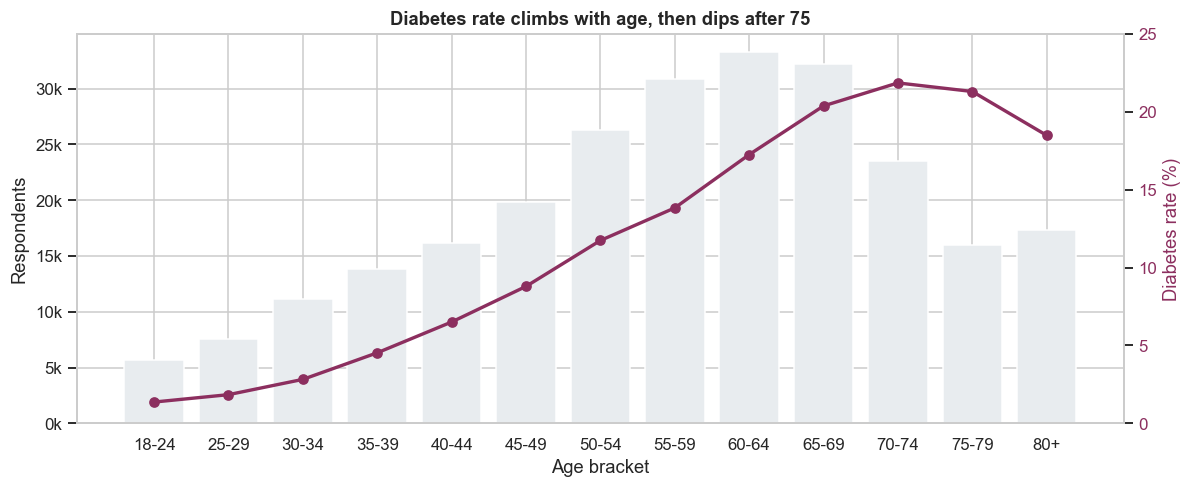

,pct_diabetes,pct_prediabetes,n
18-24,1.400,0.400,5700.000
25-29,1.800,0.700,7598.000
30-34,2.800,0.600,11123.000
35-39,4.500,1.000,13823.000
40-44,6.500,1.000,16157.000
45-49,8.800,1.600,19819.000
50-54,11.700,1.600,26314.000
55-59,13.800,1.800,30832.000
60-64,17.200,2.100,33244.000
65-69,20.400,2.200,32194.000


In [22]:
age_labels = ["18-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54",
 "55-59", "60-64", "65-69", "70-74", "75-79", "80+"]

age_rate = df.groupby("Age").apply(
 lambda g: pd.Series({
 "pct_diabetes": 100 * (g.Diabetes_012 == 2).mean(),
 "pct_prediabetes": 100 * (g.Diabetes_012 == 1).mean(),
 "n": len(g),
 }), include_groups=False
)
age_rate.index = age_labels

fig, ax1 = plt.subplots(figsize=(11, 4.6))
ax1.bar(age_rate.index, age_rate.n, color="#e8ecef", edgecolor="white",
 label="Respondents (right axis)")
ax1.set_ylabel("Respondents")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax1.set_xlabel("Age bracket")

ax2 = ax1.twinx()
ax2.plot(age_rate.index, age_rate.pct_diabetes, marker="o", color=C_DIA,
 linewidth=2.2, label="Diabetes rate")
ax2.set_ylabel("Diabetes rate (%)", color=C_DIA)
ax2.tick_params(axis="y", labelcolor=C_DIA)
ax2.grid(False)
ax2.set_ylim(0, 25)

ax1.set_title("Diabetes rate climbs with age, then dips after 75")
plt.tight_layout()
plt.show()

age_rate.round(1)

Age is ordinal with evenly spaced brackets, so a **line** works here. A line implies a
progression between adjacent categories, which is true for age in a way it would not be
for a nominal variable. We put it over **bars showing sample size**, because the rate in
a sparse bracket is less reliable and the reader needs both to judge the trend.

A dual axis is usually a bad idea. Here the two series answer different questions about
the same x-axis, and the alternative of two stacked panels would make the comparison
harder.

### Interpretation

The diabetes rate rises steeply and monotonically from **1.4% in the 18–24 bracket to
21.8% at 70–74**, then **falls** to 18.5% in the 80+ bracket.

That final dip is almost certainly not a real decline in risk, and two mechanisms
explain it, both of them artifacts:

1. **Survivor bias.** Diabetes raises mortality. People who developed it at 60 are less
 likely to reach 80, so the surviving 80+ population is selectively healthier.
2. **Survey coverage.** BRFSS is a telephone survey of non-institutionalized adults.
 The sickest 80-year-olds are disproportionately in nursing homes and never sampled.

The sample also skews substantially older than the US adult population, so the raw
13.9 percent prevalence here overstates the national figure.

In short, the curve is real up to about age 74, and the drop after that is the survey
looking at a healthier group, not a healthier age.

## 6.4 Binary health indicators — blood pressure and cholesterol show the widest gaps

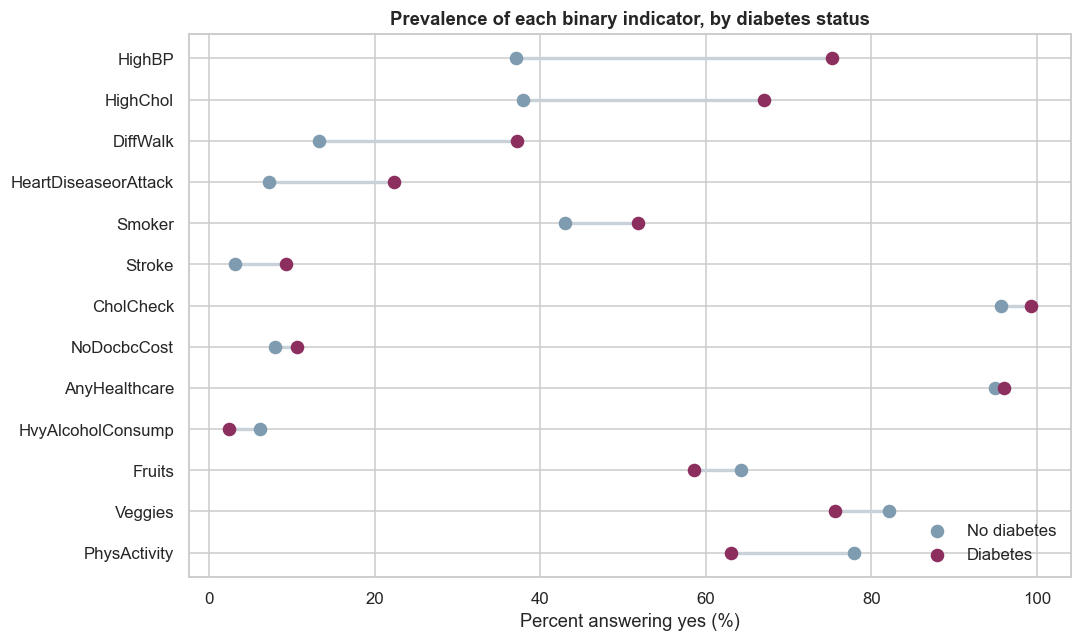

,No diabetes,Diabetes,gap
PhysActivity,77.900,63.100,-14.900
Veggies,82.100,75.600,-6.500
Fruits,64.300,58.500,-5.800
HvyAlcoholConsump,6.200,2.400,-3.800
AnyHealthcare,95.000,96.000,1.000
NoDocbcCost,8.000,10.600,2.600
CholCheck,95.700,99.300,3.600
Stroke,3.200,9.200,6.100
Smoker,43.000,51.800,8.900
HeartDiseaseorAttack,7.200,22.300,15.100


In [23]:
binary_vars = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
 "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
 "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk"]

rates = pd.DataFrame({
 "No diabetes": [100 * df.loc[df.Diabetes_012 == 0, v].mean() for v in binary_vars],
 "Diabetes": [100 * df.loc[df.Diabetes_012 == 2, v].mean() for v in binary_vars],
}, index=binary_vars)
rates["gap"] = rates["Diabetes"] - rates["No diabetes"]
rates = rates.sort_values("gap")

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(rates))
ax.hlines(y, rates["No diabetes"], rates["Diabetes"], color="#c9d2d8", linewidth=2.2)
ax.scatter(rates["No diabetes"], y, color=C_NO, s=62, label="No diabetes", zorder=3)
ax.scatter(rates["Diabetes"], y, color=C_DIA, s=62, label="Diabetes", zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(rates.index)
ax.set_xlabel("Percent answering yes (%)")
ax.set_title("Prevalence of each binary indicator, by diabetes status")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

rates.round(1)

A **dot (dumbbell) plot** is the right choice for comparing one paired measurement
across thirteen categories. The alternative, thirteen side-by-side bar pairs, would use far more ink for the same
information. The quantity of interest is the **gap** between two points, which the connecting line
encodes directly, and sorting by gap size turns the chart into a ranking.

### Interpretation

The ordering is informative, with the largest gaps at high blood pressure (+38 points),
high cholesterol (+29), and walking difficulty (+24). These are the metabolic-syndrome cluster, conditions that
share underlying causes with diabetes rather than merely correlating with it.

Two results run counter to intuition:

- **`HvyAlcoholConsump` is **lower** among diabetics** (2.4% vs. 6.2%). This does not mean
 heavy drinking protects against diabetes. It is confounded: heavy drinkers skew
 younger, and age is the dominant risk factor. It may also reflect reverse causation,
 since people diagnosed with diabetes are advised to cut back.
- **`CholCheck` and `AnyHealthcare` are higher among diabetics.** This is pure reverse
 causation, being diagnosed with diabetes requires seeing a doctor. These variables
 partly encode **healthcare access**, not disease risk, and a model given them would
 learn "this person sees doctors, therefore they have a diagnosis."

Fruit and vegetable intake show almost no gap, and that null is genuinely interesting.
The diet variables in this survey are too crude to capture dietary quality, because a
yes or no daily threshold says nothing about how much or what kind.

So the useful separation here comes from diagnosed conditions, not from the lifestyle
questions.

## 6.5 Income and Education — a threefold gradient that is not perfectly monotonic

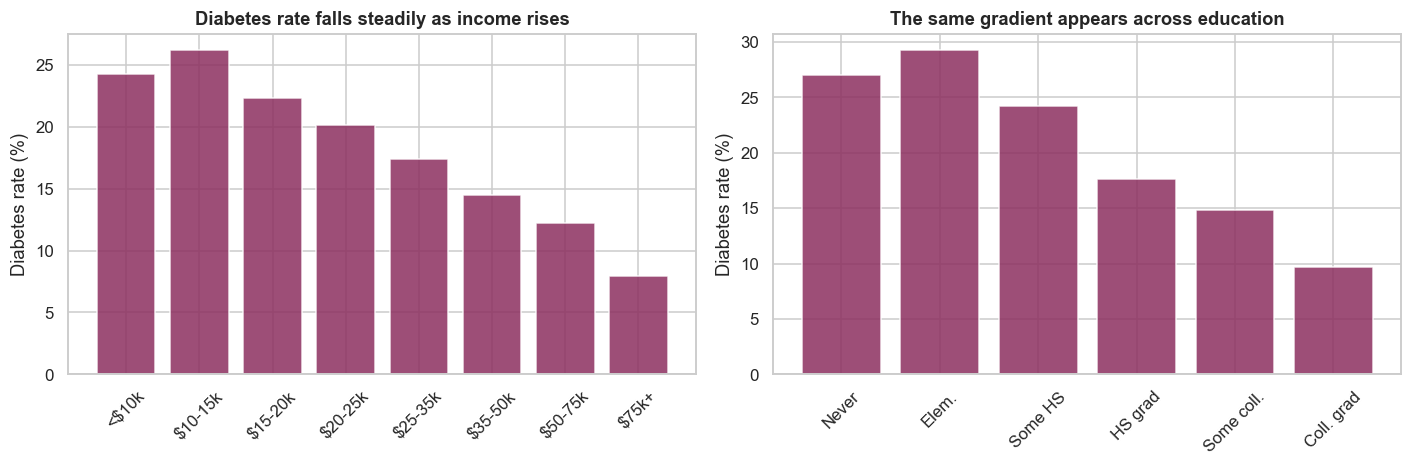

Income gradient: 24.3% (lowest) -> 8.0% (highest)
Education gradient: 27.0% (lowest) -> 9.7% (highest)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

inc_labels = ["<$10k", "$10-15k", "$15-20k", "$20-25k", "$25-35k", "$35-50k", "$50-75k", "$75k+"]
inc = df.groupby("Income").apply(
 lambda g: 100 * (g.Diabetes_012 == 2).mean(), include_groups=False)
axes[0].bar(inc_labels, inc.values, color=C_DIA, alpha=0.85, edgecolor="white")
axes[0].set_ylabel("Diabetes rate (%)")
axes[0].set_title("Diabetes rate falls steadily as income rises")
axes[0].tick_params(axis="x", rotation=45)

edu_labels = ["Never", "Elem.", "Some HS", "HS grad", "Some coll.", "Coll. grad"]
edu = df.groupby("Education").apply(
 lambda g: 100 * (g.Diabetes_012 == 2).mean(), include_groups=False)
axes[1].bar(edu_labels, edu.values, color=C_DIA, alpha=0.85, edgecolor="white")
axes[1].set_ylabel("Diabetes rate (%)")
axes[1].set_title("The same gradient appears across education")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Income gradient:", f"{inc.iloc[0]:.1f}% (lowest) -> {inc.iloc[-1]:.1f}% (highest)")
print("Education gradient:", f"{edu.iloc[0]:.1f}% (lowest) -> {edu.iloc[-1]:.1f}% (highest)")

Both are ordinal, so bar charts in their natural order are appropriate, and we show them
side by side because the same gradient appears in two different socioeconomic measures.

### Interpretation

The gradient is steep but **not perfectly monotonic**. The rate peaks in the second
bracket (\$10 to 15k, about 26 percent) rather than the lowest (under \$10k, about
24 percent). From there it falls steadily to about 8 percent in the top bracket, a
factor of roughly three. Education behaves the same way, peaking at about 29 percent
before falling to about 10 percent among college graduates.

That first step matters for modeling, because a linear term on income slightly misfits
the bottom of the range.

These two variables correlate 0.45 with each other, so they are substantially measuring
the same underlying construct (socioeconomic position). A model including both gets
less additional information from the second than their individual correlations suggest.

The mechanism is not that low income causes diabetes directly, but that it runs through
food environment, time and facilities for physical activity, chronic stress, and
healthcare access. The last of those cuts both ways. Lower-income respondents have less access to
screening, so their true diabetes rate is probably **understated** relative to
higher-income respondents.

The takeaway is that the real gradient is likely steeper than this chart shows.

# 7. Relationships Between ALL Attributes

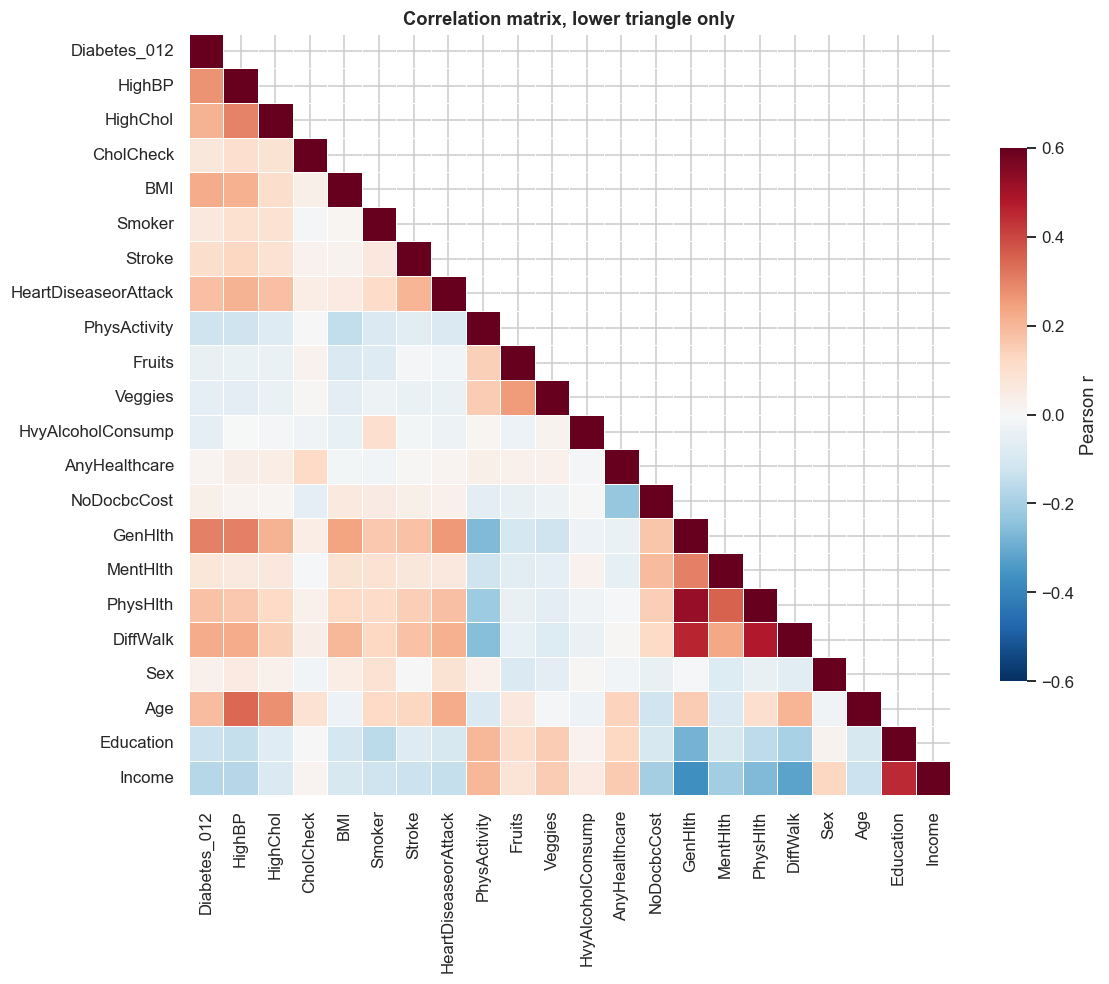

In [25]:
corr = df.drop(columns=["BMI_capped"]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
 square=True, linewidths=0.4, cbar_kws={"shrink": 0.7, "label": "Pearson r"},
 annot=False, ax=ax)
ax.set_title("Correlation matrix, lower triangle only")
plt.tight_layout()
plt.show()

A **heatmap** is the standard choice for 22 × 22 pairwise correlations, because a table
of 484 numbers is unreadable while color makes the structure visible immediately. We masked the
upper triangle because a correlation matrix is symmetric and showing both halves
doubles the ink for zero extra information. The colormap is **diverging and centered at
zero** so that positive and negative associations are visually distinct, which a
sequential colormap would obscure.

We did not annotate the cells; at this size the numbers would be unreadable, and the
exact values for the target appear in the ranked table below.

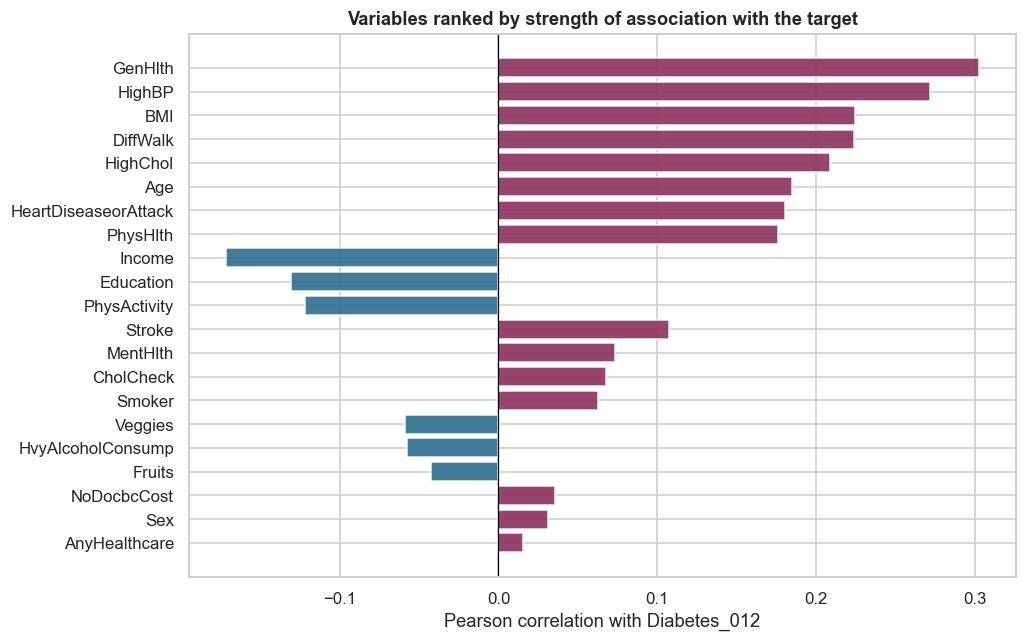

,r
GenHlth,0.303
HighBP,0.272
BMI,0.224
DiffWalk,0.224
HighChol,0.209
Age,0.185
HeartDiseaseorAttack,0.180
PhysHlth,0.176
Income,-0.171
Education,-0.131


In [26]:
target_corr = (corr["Diabetes_012"]
 .drop("Diabetes_012")
 .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9.5, 6))
colors = [C_DIA if v > 0 else "#2c6e8f" for v in target_corr.values]
ax.barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.9)
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with Diabetes_012")
ax.set_title("Variables ranked by strength of association with the target")
plt.tight_layout()
plt.show()

target_corr.round(3).to_frame("r")

### Interpretation

No single variable correlates above about 0.31, so there is no dominant predictor here.
Diabetes risk in this data is built from many moderate signals rather than one strong
one.

So this argues for methods that combine weak signals well, and against expecting a
simple rule to work.

A caution on the method itself: **Pearson correlation assumes a linear relationship
between numeric variables**, and most columns here are binary or ordinal codes. For
binary variables the coefficient is mathematically valid (it reduces to a point-biserial
correlation), but for ordinal codes like `Age` it measures only the **linear** component
of the trend. Section 6.3 showed `Age` is non-monotonic at the top end, and the
correlation of 0.185 cannot see that. A low correlation here does not prove there is no relationship.

In [27]:
# Redundancy among predictors, not just with the target
pred_corr = corr.drop(index="Diabetes_012", columns="Diabetes_012").abs()
pairs = (pred_corr.where(np.triu(np.ones(pred_corr.shape, dtype=bool), k=1))
 .stack().sort_values(ascending=False).head(8))

print("Most strongly correlated predictor pairs:")
for (a, b), v in pairs.items():
 print(f" {a:<22} ~ {b:<22} r = {v:.2f}")

Most strongly correlated predictor pairs:
 GenHlth                ~ PhysHlth               r = 0.52
 PhysHlth               ~ DiffWalk               r = 0.48
 GenHlth                ~ DiffWalk               r = 0.46
 Education              ~ Income                 r = 0.45
 GenHlth                ~ Income                 r = 0.37
 MentHlth               ~ PhysHlth               r = 0.35
 HighBP                 ~ Age                    r = 0.34
 DiffWalk               ~ Income                 r = 0.32


This is the redundancy that matters for modeling. `GenHlth`, `PhysHlth`, and `DiffWalk`
form a cluster (pairwise r ≈ 0.46–0.52) all measuring current physical functioning, and
`Education`–`Income` (r = 0.45) measure socioeconomic position.

Correlated predictors do not hurt tree-based models much, but they destabilize linear
model coefficients and make feature-importance scores misleading, importance gets
split arbitrarily among members of a correlated group. If interpretability were the
goal, we would collapse each cluster into a single composite.

In [28]:
# Cross-tabulation: how risk factors combine
combo = (df.assign(is_dia=(df.Diabetes_012 == 2))
 .groupby(["HighBP", "HighChol"])
 .agg(rate=("is_dia", lambda s: 100 * s.mean()), n=("is_dia", "size")))
combo.index = pd.MultiIndex.from_tuples(
 [("No high BP", "No high chol"), ("No high BP", "High chol"),
 ("High BP", "No high chol"), ("High BP", "High chol")])
combo.round(1)

rate       n
No high BP No high chol  4.200  101920
           High chol    10.400   42931
High BP    No high chol 16.700   44169
           High chol    29.700   64660

### Interpretation

The combination is informative beyond either variable alone. Someone with **neither**
condition has about a 4 percent diabetes rate, and someone with **both** has about
30 percent, roughly a sevenfold difference. Having just
one lands in between: 10.4% with high cholesterol alone, 16.7% with high blood pressure
alone.

High blood pressure is clearly the stronger of the two on its own. The joint rate is
roughly what independent multiplicative effects would predict, so these two are not
redundant with each other. We keep both, and their interaction may add signal that a
purely additive model would miss.

# 8. Group-Wise Comparison

In [29]:
profile = df.groupby("Diabetes_012").agg(
 n=("BMI", "size"),
 bmi_median=("BMI", "median"),
 bmi_mean=("BMI", "mean"),
 pct_highbp=("HighBP", lambda s: 100 * s.mean()),
 pct_highchol=("HighChol", lambda s: 100 * s.mean()),
 genhlth_mean=("GenHlth", "mean"),
 age_median=("Age", "median"),
 physhlth_mean=("PhysHlth", "mean"),
 pct_diffwalk=("DiffWalk", lambda s: 100 * s.mean()),
 income_median=("Income", "median"),
).round(2)
profile.index = labels
profile.T

,No diabetes,Prediabetes,Diabetes
n,213703.000,4631.000,35346.000
bmi_median,27.000,30.000,31.000
bmi_mean,27.740,30.720,31.940
pct_highbp,37.110,62.900,75.270
pct_highchol,37.920,62.080,67.010
genhlth_mean,2.370,2.980,3.290
age_median,8.000,9.000,10.000
physhlth_mean,3.580,6.350,7.950
pct_diffwalk,13.230,27.750,37.120
income_median,7.000,6.000,6.000


### Interpretation

Reading across the three columns, prediabetes sits **consistently between** the other
two classes on nearly every measure, BMI, blood pressure, cholesterol, general health,
walking difficulty.

It is also why prediabetes will be hard to classify, since the class has no profile of
its own. It is an intermediate zone on a continuum, and with only 4,631 examples and
unreliable labeling a model has very little to latch onto.

In short, prediabetes sits between the two other classes on every measure, which is
exactly what makes it hard to separate from them.

Note that `age_median` is a bracket index, not years: 8 = 55–59 and 10 = 65–69.

# 9. Proposed Feature Engineering Variables

We construct four candidate features here and test whether they actually separate the
classes.

In [30]:
d = df.copy()

# 1. Clinical BMI categories rather than a raw number
d["BMI_category"] = pd.cut(
 d.BMI, bins=[0, 18.5, 25, 30, 35, 40,200],
 labels=["Underweight", "Normal", "Overweight", "Obese I", "Obese II", "Obese III"],
 right=False)

# 2. Banded poor-health days (handles the zero-inflation from Section 4.4)
def band_days(s):
 return pd.cut(s, bins=[-0.1, 0.5, 13.5, 29.5, 30.1],
 labels=["0 days", "1-13", "14-29", "all 30"])

d["MentHlth_band"] = band_days(d.MentHlth)
d["PhysHlth_band"] = band_days(d.PhysHlth)

# 3. Count of cardiovascular comorbidities
d["CardioRisk"] = d[["HighBP", "HighChol", "HeartDiseaseorAttack", "Stroke"]].sum(axis=1)

# 4. Healthy-lifestyle score
d["LifestyleScore"] = (d.PhysActivity + d.Fruits + d.Veggies
 + (1 - d.Smoker) + (1 - d.HvyAlcoholConsump))

print(d[["BMI_category", "MentHlth_band", "CardioRisk", "LifestyleScore"]].head())

  BMI_category MentHlth_band  CardioRisk  LifestyleScore
0    Obese III         14-29       2.000           2.000
1   Overweight        0 days       0.000           2.000
2   Overweight        all 30       2.000           3.000
3   Overweight        0 days       1.000           5.000
4       Normal          1-13       2.000           5.000


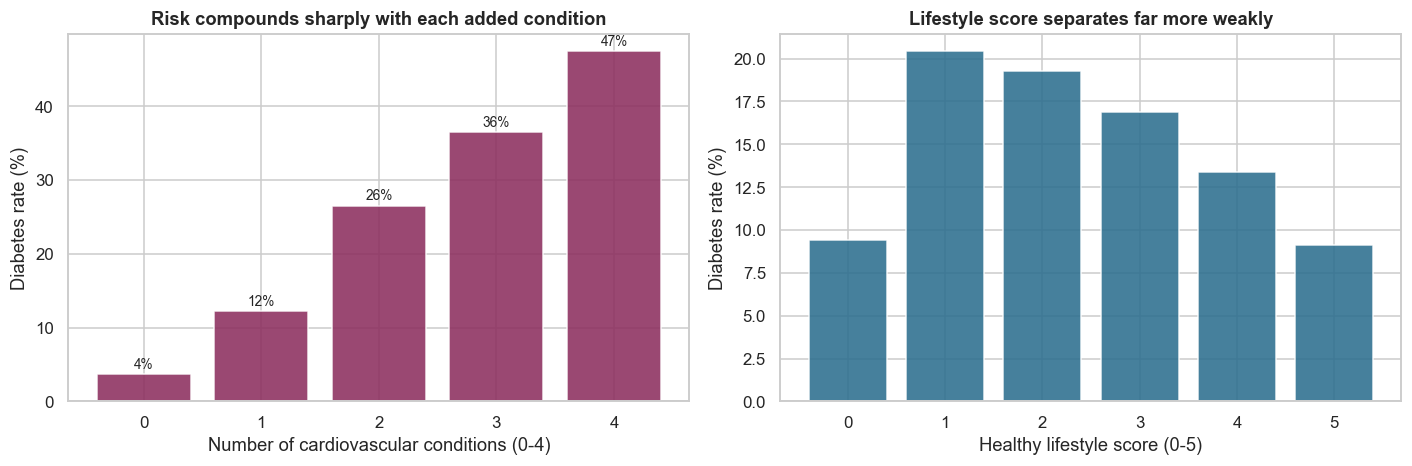

CardioRisk : {0.0: 3.7, 1.0: 12.2, 2.0: 26.5, 3.0: 36.4, 4.0: 47.4}
Lifestyle : {0.0: 9.4, 1.0: 20.4, 2.0: 19.3, 3.0: 16.9, 4.0: 13.4, 5.0: 9.1}


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

cardio = d.groupby("CardioRisk").apply(
 lambda g: pd.Series({"rate": 100*(g.Diabetes_012==2).mean(), "n": len(g)}),
 include_groups=False)
axes[0].bar(cardio.index.astype(int).astype(str), cardio.rate,
 color=C_DIA, alpha=0.88, edgecolor="white")
axes[0].set_xlabel("Number of cardiovascular conditions (0-4)")
axes[0].set_ylabel("Diabetes rate (%)")
axes[0].set_title("Risk compounds sharply with each added condition")
for i, (r, n) in enumerate(zip(cardio.rate, cardio.n)):
 axes[0].text(i, r + 0.8, f"{r:.0f}%", ha="center", fontsize=9)

life = d.groupby("LifestyleScore").apply(
 lambda g: pd.Series({"rate": 100*(g.Diabetes_012==2).mean(), "n": len(g)}),
 include_groups=False)
axes[1].bar(life.index.astype(int).astype(str), life.rate,
 color="#2c6e8f", alpha=0.88, edgecolor="white")
axes[1].set_xlabel("Healthy lifestyle score (0-5)")
axes[1].set_ylabel("Diabetes rate (%)")
axes[1].set_title("Lifestyle score separates far more weakly")

plt.tight_layout()
plt.show()

print("CardioRisk :", cardio.rate.round(1).to_dict())
print("Lifestyle :", life.rate.round(1).to_dict())

### Which engineered features are worth keeping

**`CardioRisk` works well.** The diabetes rate climbs from about 4 percent with zero
conditions to about 47 percent with all four. That is a cleaner, steeper gradient than
any of its four components on their own. It also compresses four sparse binary columns
into one ordinal variable, which handles the near-constant-column problem from
Section 4.4.

**`LifestyleScore` works poorly.** The gradient is shallow and not fully monotonic. Its
components are weak on their own, with fruit at r = −0.04 and vegetables at r = −0.06.
Summing weak, crudely measured signals does not manufacture a strong one. Weighting
each component equally is also hard to defend, because quitting smoking and eating fruit
daily are not comparable interventions.

So we would not use this feature. We report it because the negative result is useful.

### Other features we could build, and one we should not

Feasible from this data:

- **`BMI × Age` interaction.** Obesity at 30 may carry different implications than at 70.
- **`HealthcareAccess` composite** from `AnyHealthcare`, `NoDocbcCost`, and `CholCheck`,
 used as a **control** to adjust for diagnosis likelihood rather than as a predictor of
 disease.
- **`PoorHealthDays`** combining `MentHlth` and `PhysHlth` into a single banded burden
 measure.

Would require external data:

- **State-level food-environment or deprivation indices**, joined on the state field.
 That field is present in the raw BRFSS but stripped from this extract.

**One to avoid:** any feature built mainly from `CholCheck` or `AnyHealthcare` as a
predictor. Section 6.4 showed these encode healthcare contact, so a model using them
learns to predict who gets diagnosed rather than who has diabetes. It would score well on this
data and then fail on exactly the undiagnosed people it should be finding.

# 10. Dimensionality Reduction

We apply principal component analysis and then interpret what it does, and does not,
reveal about the structure of the data.

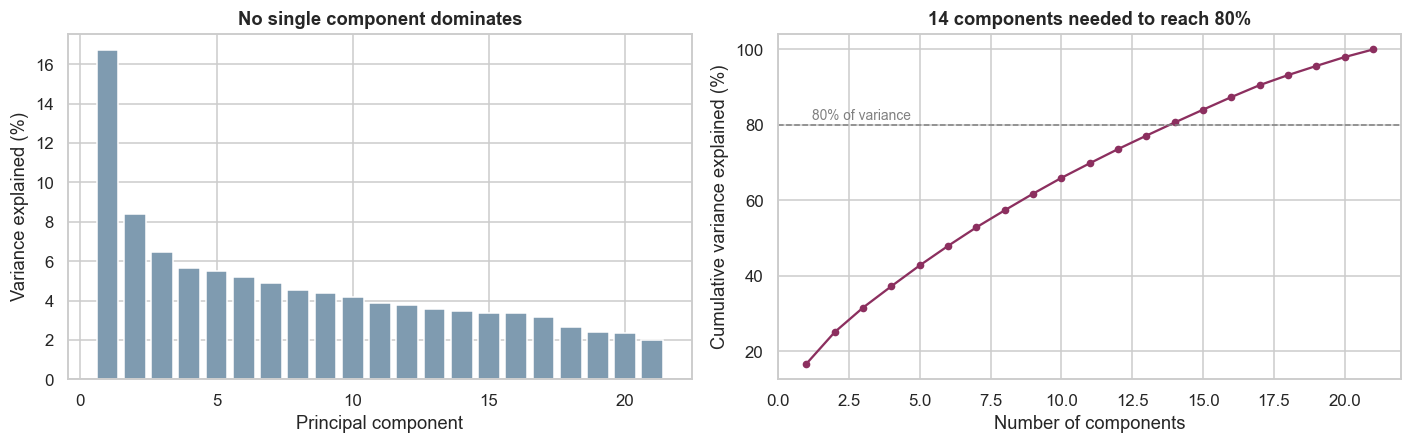

PC1 explains 16.7% of variance
PC1 + PC2: 25.1%
Components needed for 80%: 14


In [32]:
features = [c for c in df.columns if c not in ("Diabetes_012", "BMI_capped")]

X = StandardScaler().fit_transform(df[features])
pca_full = PCA().fit(X)

evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(range(1, len(evr)+1), 100*evr, color=C_NO, edgecolor="white")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("No single component dominates")

axes[1].plot(range(1, len(cum)+1), 100*cum, marker="o", color=C_DIA, markersize=4)
axes[1].axhline(80, color="grey", linestyle="--", linewidth=1)
axes[1].text(1.2, 81.5, "80% of variance", fontsize=9, color="grey")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance explained (%)")
axes[1].set_title("14 components needed to reach 80%")
plt.tight_layout()
plt.show()

print(f"PC1 explains {100*evr[0]:.1f}% of variance")
print(f"PC1 + PC2: {100*cum[1]:.1f}%")
print(f"Components needed for 80%: {int(np.argmax(cum >= 0.80)) + 1}")

### Interpretation of the variance structure

PC1 captures only 16.7% of the variance, and reaching 80% takes 14 of the 21
components. **This dataset does not compress well**, and that is a substantive finding
rather than a failed technique.

It means the 21 variables are largely measuring **different** things. There is no small
set of hidden factors driving everything, which is consistent with the correlation
analysis in Section 7, where no pair exceeded 0.52. For modeling, this argues against
using PCA for dimensionality reduction here: dropping components would discard real
information, and 21 features is not a burdensome number to begin with.

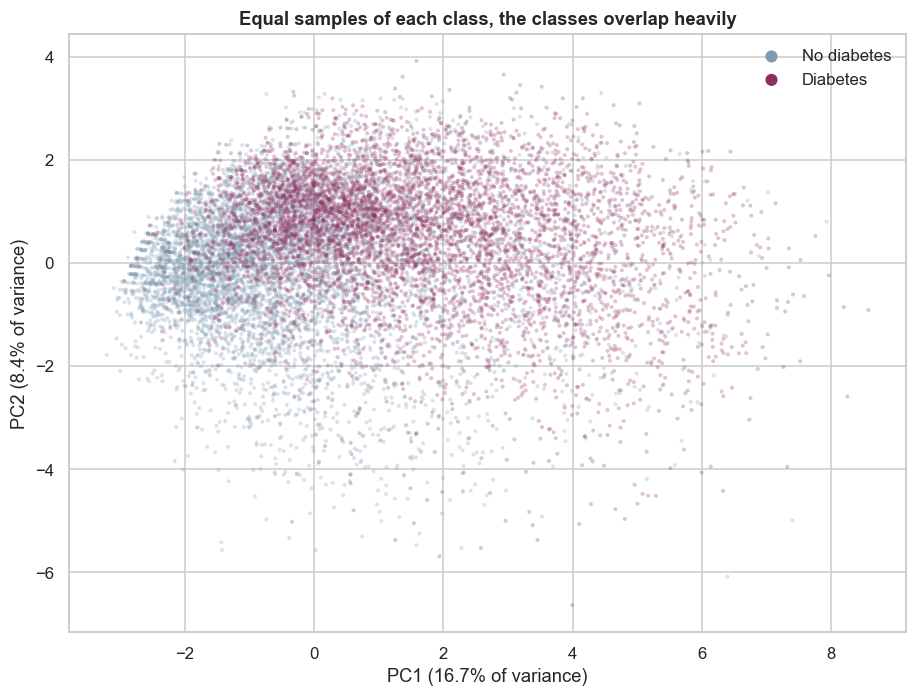

In [33]:
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(X)

# Plot a stratified sample, 253,680 overlapping points would be an unreadable blob
rng = np.random.default_rng(42)
idx_no = rng.choice(np.where(df.Diabetes_012 == 0)[0], 6000, replace=False)
idx_dia = rng.choice(np.where(df.Diabetes_012 == 2)[0], 6000, replace=False)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.scatter(coords[idx_no, 0], coords[idx_no, 1], s=7, alpha=0.28,
 color=C_NO, label="No diabetes", edgecolors="none")
ax.scatter(coords[idx_dia, 0], coords[idx_dia, 1], s=7, alpha=0.28,
 color=C_DIA, label="Diabetes", edgecolors="none")
ax.set_xlabel(f"PC1 ({100*pca2.explained_variance_ratio_[0]:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({100*pca2.explained_variance_ratio_[1]:.1f}% of variance)")
ax.set_title("Equal samples of each class, the classes overlap heavily")
leg = ax.legend(frameon=False, markerscale=3)
for h in leg.legend_handles:
 h.set_alpha(1)
plt.tight_layout()
plt.show()

Plotting all 253,680 points would produce an unreadable blob. A random sample would be
worse than useless here, because with about 84 percent of points in class 0 the diabetic
points would be buried underneath. Sampling 6,000 from each class makes the comparison visible, and the tradeoff is that
the plot no longer shows relative class sizes, which Section 5 already established.

### Interpretation

The two classes are **not linearly separable in this projection**, and they overlap
heavily, with the diabetic cloud shifted toward positive PC1 but occupying largely the
same region.

This overlap tells us something real about the data. If diabetes status were determined by a simple linear
combination of these variables, the classes would separate here. They do not. Either the
relationship is non-linear, or these 21 variables do not carry enough information to
determine diabetes status with confidence.

The takeaway is that a well-tuned model on this data should rank risk usefully, not
classify individuals reliably.

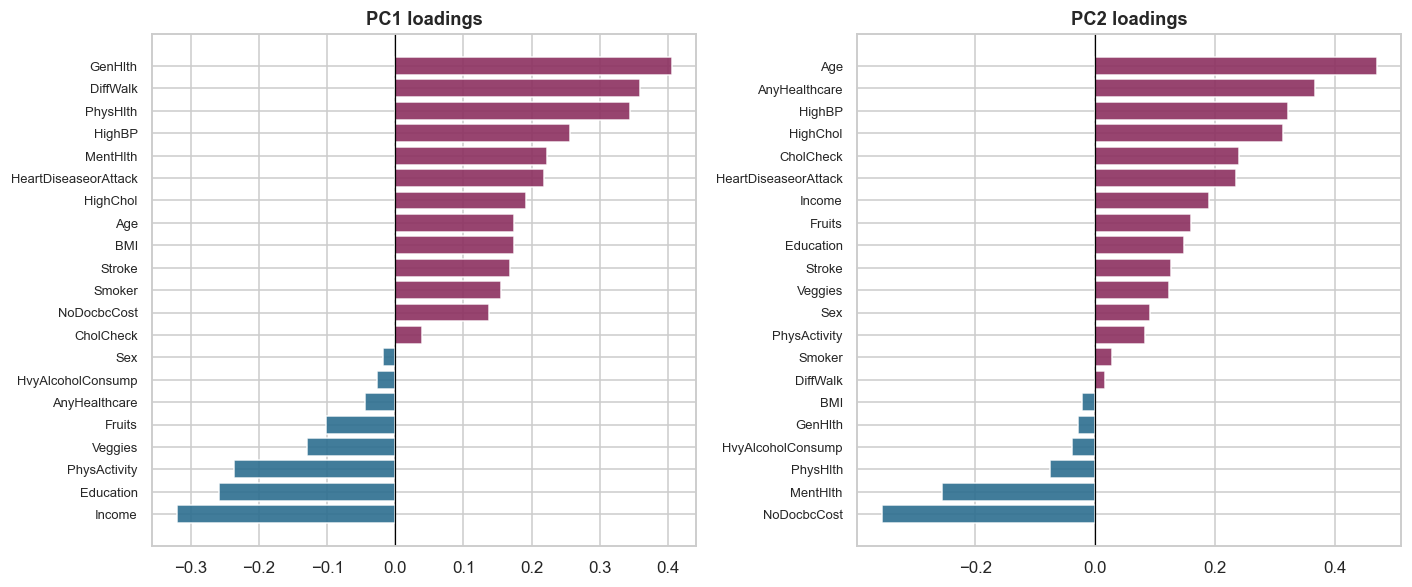

In [34]:
loadings = pd.DataFrame(
 pca2.components_.T, index=features, columns=["PC1", "PC2"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
 s = loadings[pc].sort_values()
 ax.barh(range(len(s)), s.values,
 color=[C_DIA if v > 0 else "#2c6e8f" for v in s.values], alpha=0.9)
 ax.set_yticks(range(len(s)))
 ax.set_yticklabels(s.index, fontsize=8.5)
 ax.axvline(0, color="black", linewidth=0.8)
 ax.set_title(f"{pc} loadings")
plt.tight_layout()
plt.show()

### What the components mean

**PC1** loads positively on `GenHlth`, `PhysHlth`, `DiffWalk`, `HighBP`, and
`HeartDiseaseorAttack`, and negatively on `Income`, `Education`, and `PhysActivity`. It
is best read as a **general burden-of-illness and disadvantage axis**, poor health and
low socioeconomic position at one end, good health and higher status at the other.

**PC2** separates the socioeconomic and lifestyle variables from the acute clinical
ones, distinguishing "young, lower-income, fewer diagnosed conditions" from "older,
established clinical conditions."

PC1 mixes health status with socioeconomic position, so in this data those two are
entangled rather than separable. Any model built here will partly be learning socioeconomic
position, and that carries fairness implications that belong on the record before
anyone deploys it.

# 11. Key Findings

**1. No single variable is a strong predictor.** The maximum correlation with the target
is 0.30 (`GenHlth`). Diabetes risk here is built from many moderate signals, which
argues for models that combine weak evidence rather than simple rules.

**2. The metabolic cluster carries the most signal.** `HighBP` (+38 points prevalence
gap), `HighChol` (+29), and elevated BMI (median 31 vs. 27) consistently separate the
classes. Their **combination** is stronger than any individually: having both high BP and
high cholesterol raises the diabetes rate from 4.2% to 29.7%.

**3. The strongest correlate is partly a consequence, not a cause.** `GenHlth` leads the
ranking, but self-rated health declines **because** of diabetes as much as it precedes it.
Useful for screening, misleading for causal claims.

**4. Age dominates, but non-monotonically.** The rate rises from 1.4% to 21.8% by age
70–74, then falls in the 80+ bracket, survivor bias and the exclusion of
institutionalized adults, not reduced risk.

**5. There is a steep socioeconomic gradient.** Roughly 24–26% in the lowest income
brackets versus 8.0% in the highest, with the same pattern across education. Because
lower-income respondents also have less screening access, the true gradient is probably
steeper than measured.

**6. Some variables measure healthcare access, not health.** `CholCheck` and
`AnyHealthcare` are **higher** among diabetics through reverse causation. Using them as
predictors would teach a model to identify who gets diagnosed rather than who is sick.

**7. Several intuitive variables carry almost nothing.** `Fruits` (r = −0.04),
`Veggies` (−0.06), and `Sex` (0.03) are effectively uninformative, the diet measures
are too crude to capture dietary quality.

**8. The data does not compress.** PCA needs 14 of 21 components for 80% of variance, and
the classes overlap heavily in the top two. The variables measure genuinely different
things, and the available information does not determine diabetes status.

**9. Duplicate rows are a feature of coarse coding, not an error.** 9.4% of rows are exact
duplicates; removing them would inflate the apparent diabetes rate by 1.3 points by
preferentially deleting healthy profiles.

**10. The labels record diagnosis, not disease.** This is the deepest limitation. Every
result above describes **diagnosed** diabetes, and the undiagnosed are silently coded as
negative, concentrated exactly among the low-access populations where risk is highest.

# 12. Conclusion

This notebook worked through the Business Understanding and Data Understanding phases
of CRISP-DM for the BRFSS 2015 diabetes dataset.

The data is technically clean, with no missing values, no out-of-range codes, and
consistent types, but "technically clean" and "ready to model" are not the same thing.

The substantive problems are structural. Class imbalance is severe, the prediabetes
class is both tiny and unreliably labeled, and neither is fixable by cleaning. Several variables encode healthcare access
rather than health, and the target itself measures diagnosis rather than disease.

Our cleaning decisions were conservative on purpose. We deleted no rows, capped rather
than removed BMI outliers, and kept all duplicates after showing that removing them
would push the headline prevalence up by about 1.3 points. Where a problem could not be
fixed in the data, the diagnosis-versus-disease gap above all, we documented it instead
of obscuring it.

For the modeling phase that follows, three considerations come to mind and worth exploring as a next step:

1. **Evaluate with PR-AUC and recall, not just accuracy given its limitations**, and compare every result
 against the 84.2% accuracy floor given how skewed the target variable is.
2. **Withhold the healthcare-access variables** from any model intended to identify
 undiagnosed cases, and use them instead as controls.
3. **Change target to a binary classification.** Binary classification of diagnosed
 diabetes is the better-supported task, given how small the prediabetes class is.

The appendix that follows takes these three considerations and fits one baseline model
against them, this is just a proof of concept for now, for my own curiosity. More in-depth modeling will be explored in future labs.

# Appendix — Baseline Model: The Proof of Concept

This appendix is a preview. The point is to check whether the conclusions from Key
Findings (Section 11) actually hold up when a model is fit, and to set a reference
point that later work has to beat.

Four decisions come straight out of the findings above:

1. **Predict class 2 against the rest.** The Target Variable (Section 5) showed
   prediabetes has only 4,631 examples and no profile of its own, so a three-class
   model would report near-zero recall for it. The binary task is the better one for
   this reason.
2. **Withhold the healthcare-access variables.** Finding 6 showed `CholCheck`,
   `AnyHealthcare`, and `NoDocbcCost` encode contact with the health system. A model
   given them learns who gets diagnosed rather than who is sick. We drop all three and
   fit on the remaining 18.
3. **Keep every row, including duplicates.** Duplicate Rows (Section 4.2) showed that
   dropping them pushes the prevalence up by about 1.3 points. We split on the full
   data.
4. **Judge it on recall and PR-AUC, never bare accuracy.** Finding on class imbalance
   sets the floor at about 86 percent accuracy for a model that predicts nobody has
   diabetes.

Logistic regression is the right first model here. Finding 1 shows the signal is spread
across many moderate predictors rather than concentrated in one, and Finding 8 shows the
data does not compress. An additive model over standardized features is a fair test
before anything more flexible is tried.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score,
                             precision_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix)

# Binary target: diagnosed diabetes against everyone else
y = (df.Diabetes_012 == 2).astype(int)

# Drop the target and the three healthcare-access variables from Finding 6
ACCESS = ["CholCheck", "AnyHealthcare", "NoDocbcCost"]
X = df.drop(columns=["Diabetes_012", "BMI_capped"] + ACCESS)

# 70/30 split, stratified so both sides carry the same class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Features used:  {X.shape[1]}  (dropped {', '.join(ACCESS)})")
print(f"Training rows:  {len(X_train):,}   positive rate {y_train.mean():.3f}")
print(f"Test rows:      {len(X_test):,}    positive rate {y_test.mean():.3f}")

Features used:  18  (dropped CholCheck, AnyHealthcare, NoDocbcCost)
Training rows:  177,576   positive rate 0.139
Test rows:      76,104    positive rate 0.139


In [36]:
def evaluate(name, proba, pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced acc": balanced_accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
    }

results = []

# Reference point: predict the majority class for everyone
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
results.append(evaluate("Predict nobody has diabetes",
                        dummy.predict_proba(X_test)[:, 1], dummy.predict(X_test)))

# Logistic regression at the default 0.50 threshold
logit = make_pipeline(StandardScaler(),
                      LogisticRegression(max_iter=1000, random_state=42)).fit(X_train, y_train)
p_logit = logit.predict_proba(X_test)[:, 1]
results.append(evaluate("Logistic, 0.50 threshold", p_logit, (p_logit >= 0.50).astype(int)))

# Same model, class weights balanced to reflect the cost of a missed case
logit_bal = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
).fit(X_train, y_train)
p_bal = logit_bal.predict_proba(X_test)[:, 1]
results.append(evaluate("Logistic, class-weighted", p_bal, (p_bal >= 0.50).astype(int)))

pd.DataFrame(results).set_index("Model").round(3)

,Accuracy,Balanced acc,Recall,Precision,F1,ROC-AUC,PR-AUC
Model,,,,,,,
Predict nobody has diabetes,0.861,0.500,0.000,0.000,0.000,0.500,0.139
"Logistic, 0.50 threshold",0.863,0.567,0.156,0.532,0.241,0.819,0.399
"Logistic, class-weighted",0.731,0.744,0.761,0.311,0.441,0.820,0.397


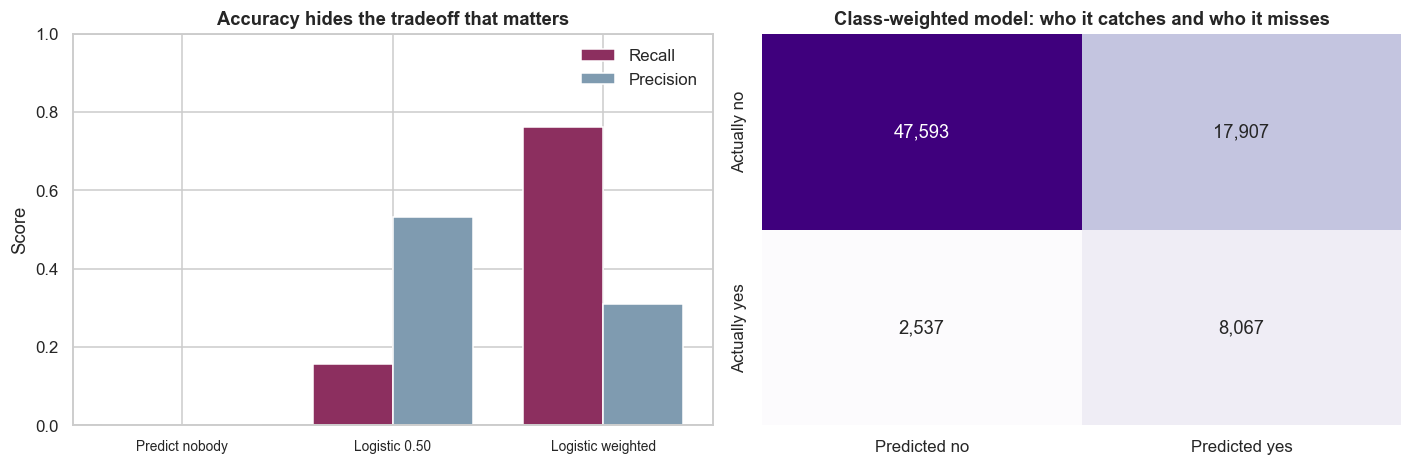

Caught 8,067 of 10,604 diabetics (76% recall)
Missed 2,537, and flagged 17,907 people who are not diagnosed diabetic


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# Recall against precision for the two thresholds, with the no-skill floor
labels_m = ["Predict nobody", "Logistic 0.50", "Logistic weighted"]
rec = [r["Recall"] for r in results]
prec = [r["Precision"] for r in results]
xpos = np.arange(len(labels_m))
w = 0.38
axes[0].bar(xpos - w/2, rec, w, label="Recall", color=C_DIA)
axes[0].bar(xpos + w/2, prec, w, label="Precision", color=C_NO)
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(labels_m, fontsize=9)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy hides the tradeoff that matters")
axes[0].legend(frameon=False)

# Confusion matrix for the class-weighted model
cm = confusion_matrix(y_test, (p_bal >= 0.50).astype(int))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Purples", cbar=False,
            xticklabels=["Predicted no", "Predicted yes"],
            yticklabels=["Actually no", "Actually yes"], ax=axes[1])
axes[1].set_title("Class-weighted model: who it catches and who it misses")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Caught {tp:,} of {tp + fn:,} diabetics ({100*tp/(tp+fn):.0f}% recall)")
print(f"Missed {fn:,}, and flagged {fp:,} people who are not diagnosed diabetic")

### Initial Insights

**The accuracy floor is something to keep an eye out for.** A model that predicts
nobody has diabetes scores about 86 percent accuracy. Logistic regression
at the standard 0.50 cutoff scores about 86 percent too, and it gets there by finding
only about 16 percent of the diabetics. On accuracy alone the two look identical. On
recall they are very different.

**Class weighting improves the model.** Weighting the classes by their inverse
frequency raises recall from about 16 percent to about 76 percent, at the cost of
precision falling to about 31 percent. Accuracy drops to about 73 percent, which is
**below** the do-nothing baseline, and that is the point here.
*Measuring the Effectiveness of a Prediction Algorithm (Section 1.3)* argued that a
missed diabetic costs more than a false alarm, and this is the tradeoff being made.

**Ranking quality is decent even though classification is not.** ROC-AUC is about 0.82
and PR-AUC about 0.40, against a no-skill floor of 0.139. Both thresholds share almost
the same AUC because they share the same underlying model. So the threshold, not the
fit, is the thing that trades recall against precision.

**The coefficients agree with the EDA.** General health, BMI, age, high blood pressure,
and high cholesterol carry the largest standardized weights. That is the same ranking
*Relationships Between ALL Attributes (Section 7)* produced by correlation, so nothing
surprising appeared once the model was fit.

The takeaway is that this dataset supports useful risk ranking and not reliable
individual classification, which is what *Dimensionality Reduction (Section 10)*
predicted. A PR-AUC near 0.40 is the number later models have to beat, and 76 percent
recall at 31 percent precision is the baseline they have to improve on.